Relation between GDP and unemployment

Unemplyment rate

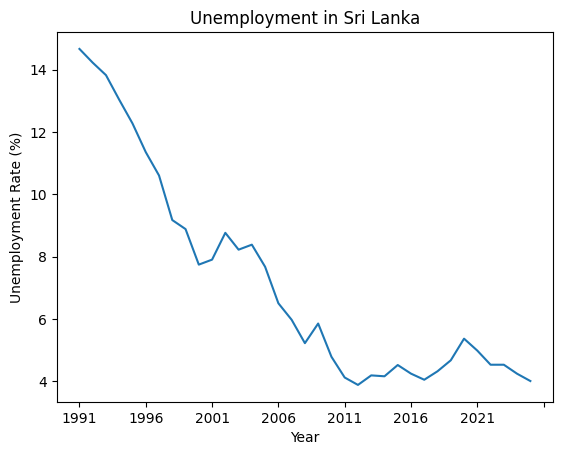

In [25]:
import pandas as pd

unemployment_sri_lanka_df = pd.read_csv(
    "labour/csv/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv",
    skiprows=4
)
unemployment_sri_lanka_df.set_index("Country Name", inplace=True)

unemployment_sri_lanka_df.loc["Sri Lanka"].dropna()[3:].plot(
    title="Unemployment in Sri Lanka",
    xlabel="Year",  
    ylabel="Unemployment Rate (%)"
)

unemployment_sri_lanka_df=unemployment_sri_lanka_df.loc["Sri Lanka"].dropna()[3:]

GDP

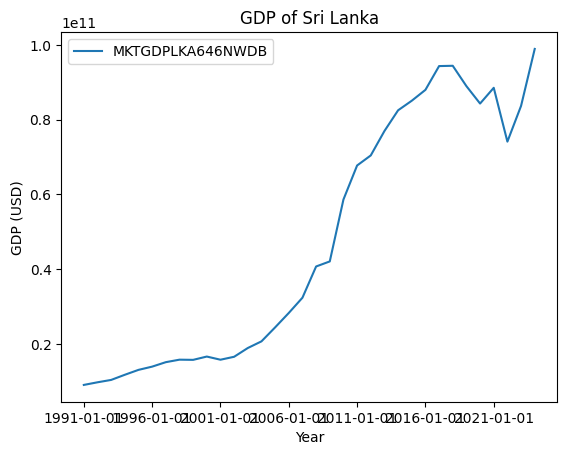

In [26]:
gdp_sri_lanka_df = pd.read_csv("economy/Gross Domestic Product for Sri Lanka.csv")
gdp_sri_lanka_df.set_index("observation_date", inplace=True)
gdp_sri_lanka_df[31:].plot(
    title="GDP of Sri Lanka",
    xlabel="Year",
    ylabel="GDP (USD)"
)

gdp_sri_lanka_df=gdp_sri_lanka_df[31:]

Correlation Analysis: Unemployment vs GDP in Sri Lanka
Years covered: 1991 - 2024
Number of data points: 34

Pearson Correlation Coefficient: -0.8375
P-value (Pearson): 0.000000

Spearman Correlation Coefficient: -0.8988
P-value (Spearman): 0.000000


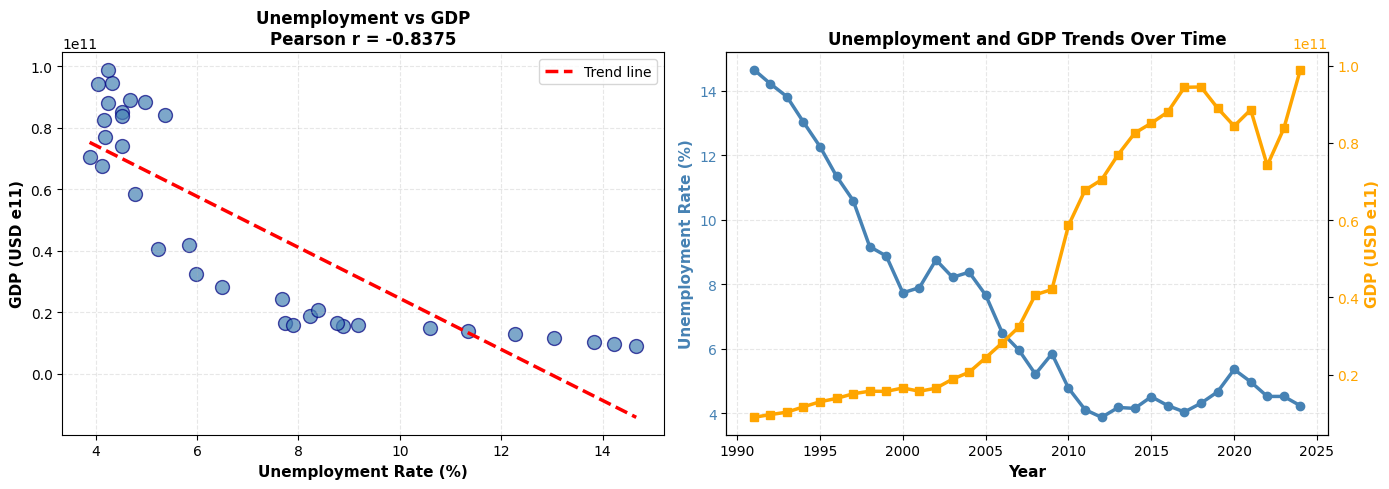


INTERPRETATION:
• Correlation Strength: strong negative
• Statistical Significance: significant (p=0.000000)

This indicates that unemployment and GDP have a strong
negative relationship in Sri Lanka over the analyzed period.


In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, pearsonr
import pandas as pd

# Extract years from unemployment index
unemployment_years = pd.to_numeric(unemployment_sri_lanka_df.index, errors='coerce')
unemployment_values = pd.to_numeric(unemployment_sri_lanka_df.values, errors='coerce')

# Extract years from GDP index by converting dates to years
gdp_df_temp = gdp_sri_lanka_df.copy()
gdp_df_temp.index = pd.to_datetime(gdp_df_temp.index, errors='coerce').year

# Get GDP values and convert to numeric
gdp_values = pd.to_numeric(gdp_df_temp.iloc[:, 0], errors='coerce').values

# Create aligned dataframes
unemployment_clean = pd.DataFrame({
    'year': unemployment_years,
    'unemployment': unemployment_values
}).dropna()
unemployment_clean['year'] = unemployment_clean['year'].astype(int)
unemployment_clean['unemployment'] = unemployment_clean['unemployment'].astype(float)

gdp_clean = pd.DataFrame({
    'year': gdp_df_temp.index,
    'gdp': gdp_values
}).dropna()
gdp_clean['year'] = gdp_clean['year'].astype(int)
gdp_clean['gdp'] = gdp_clean['gdp'].astype(float)

# Merge on common years
merged_df = unemployment_clean.merge(gdp_clean, on='year', how='inner')
merged_df = merged_df.sort_values('year')

print(f"Correlation Analysis: Unemployment vs GDP in Sri Lanka")
print(f"=" * 55)
print(f"Years covered: {int(merged_df['year'].min())} - {int(merged_df['year'].max())}")
print(f"Number of data points: {len(merged_df)}\n")

# Extract values for correlation (ensure float type)
unemployment_vals = merged_df['unemployment'].astype(float).values
gdp_vals = merged_df['gdp'].astype(float).values

# Calculate correlations
pearson_corr, pearson_pvalue = pearsonr(unemployment_vals, gdp_vals)
spearman_corr, spearman_pvalue = spearmanr(unemployment_vals, gdp_vals)

print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")
print(f"P-value (Pearson): {pearson_pvalue:.6f}")
print(f"\nSpearman Correlation Coefficient: {spearman_corr:.4f}")
print(f"P-value (Spearman): {spearman_pvalue:.6f}")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with trend line
ax1.scatter(unemployment_vals, gdp_vals, alpha=0.7, s=100, color='steelblue', edgecolors='navy')
z = np.polyfit(unemployment_vals, gdp_vals, 1)
p = np.poly1d(z)
unemployment_sorted = np.sort(unemployment_vals)
ax1.plot(unemployment_sorted, p(unemployment_sorted), "r--", linewidth=2.5, label='Trend line')
ax1.set_xlabel('Unemployment Rate (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('GDP (USD e11)', fontsize=11, fontweight='bold')
ax1.set_title(f'Unemployment vs GDP\nPearson r = {pearson_corr:.4f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Time series plot with dual y-axes
ax2.plot(merged_df['year'], unemployment_vals, marker='o', linewidth=2.5, 
         label='Unemployment Rate (%)', color='steelblue', markersize=6)
ax2_twin = ax2.twinx()
ax2_twin.plot(merged_df['year'], gdp_vals, marker='s', linewidth=2.5, 
              label='GDP (USD e11)', color='orange', markersize=6)
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Unemployment Rate (%)', fontsize=11, fontweight='bold', color='steelblue')
ax2_twin.set_ylabel('GDP (USD e11)', fontsize=11, fontweight='bold', color='orange')
ax2.set_title('Unemployment and GDP Trends Over Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2_twin.tick_params(axis='y', labelcolor='orange')

plt.tight_layout()
plt.show()

# Interpretation
print(f"\n{'='*55}")
print(f"INTERPRETATION:")
print(f"{'='*55}")

corr_abs = abs(pearson_corr)
if corr_abs < 0.3:
    strength = "weak"
elif corr_abs < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "negative" if pearson_corr < 0 else "positive"

sig_level = "significant" if pearson_pvalue < 0.05 else "not significant"
print(f"• Correlation Strength: {strength} {direction}")
print(f"• Statistical Significance: {sig_level} (p={pearson_pvalue:.6f})")
print(f"\nThis indicates that unemployment and GDP have a {strength}")
print(f"{direction} relationship in Sri Lanka over the analyzed period.")